In [50]:
import pandas as pd

df = pd.read_csv('shot_logs.csv')

df.head()

,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,...,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id
0,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,2,...,7.7,2,made,"Anderson, Alan",101187,1.3,1,2,brian roberts,203148
1,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0,...,28.2,3,missed,"Bogdanovic, Bojan",202711,6.1,0,0,brian roberts,203148
2,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,3,...,10.1,2,missed,"Bogdanovic, Bojan",202711,0.9,0,0,brian roberts,203148
3,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,2,...,17.2,2,missed,"Brown, Markel",203900,3.4,0,0,brian roberts,203148
4,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2,...,3.7,2,missed,"Young, Thaddeus",201152,1.1,0,0,brian roberts,203148


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   GAME_ID                     128069 non-null  int64  
 1   MATCHUP                     128069 non-null  object 
 2   LOCATION                    128069 non-null  object 
 3   W                           128069 non-null  object 
 4   FINAL_MARGIN                128069 non-null  int64  
 5   SHOT_NUMBER                 128069 non-null  int64  
 6   PERIOD                      128069 non-null  int64  
 7   GAME_CLOCK                  128069 non-null  object 
 8   SHOT_CLOCK                  122502 non-null  float64
 9   DRIBBLES                    128069 non-null  int64  
 10  TOUCH_TIME                  128069 non-null  float64
 11  SHOT_DIST                   128069 non-null  float64
 12  PTS_TYPE                    128069 non-null  int64  
 13  SHOT_RESULT   

In [52]:
# 1. Converting feet to meters
df['SHOT_DIST_M'] = df['SHOT_DIST'] * 0.3048

# 2. def_pressure_index
df['DEF_PRESSURE'] = df['CLOSE_DEF_DIST'] / (df['SHOT_DIST'] + 0.01)

# 3. Combining overtime quarters (5, 6, 7) into a single 'OT' category.
df['PERIOD'] = df['PERIOD'].astype(str).replace({'5': 'OT', '6': 'OT', '7': 'OT'})

# 4. Filling missing values in shot clock (SHOT_CLOCK) with median
median_time = df['SHOT_CLOCK'].median()
df['SHOT_CLOCK'] = df['SHOT_CLOCK'].fillna(median_time)

# 5. Removing unnecessary columns
columns_to_remove = ['GAME_ID', 'player_id', 'CLOSEST_DEFENDER_PLAYER_ID', 'FGM']
df = df.drop(columns_to_remove, axis=1, errors='ignore')

df[['SHOT_DIST', 'SHOT_DIST_M', 'CLOSE_DEF_DIST', 'DEF_PRESSURE', 'PERIOD', 'SHOT_CLOCK']].head()

,SHOT_DIST,SHOT_DIST_M,CLOSE_DEF_DIST,DEF_PRESSURE,PERIOD,SHOT_CLOCK
0,7.7,2.34696,1.3,0.168612,1,10.8
1,28.2,8.59536,6.1,0.216235,1,3.4
2,10.1,3.07848,0.9,0.089021,1,12.3
3,17.2,5.24256,3.4,0.197560,2,10.3
4,3.7,1.12776,1.1,0.296496,2,10.9


In [53]:
# 1. # Restrict shot distance to 99th percentile
distance_upper_bound = df['SHOT_DIST_M'].quantile(0.99)
df['SHOT_DIST_M'] = df['SHOT_DIST_M'].clip(upper=distance_upper_bound)

# 2. # Remove shot touch time anomalies using IQR rule
Q1 = df['TOUCH_TIME'].quantile(0.25)
Q3 = df['TOUCH_TIME'].quantile(0.75)
IQR = Q3 - Q1
lower_time_bound = Q1 - 1.5 * IQR
upper_time_bound = Q3 + 1.5 * IQR

# Filtering the table, keeping only the rows that fall within the standard range.
df = df[(df['TOUCH_TIME'] >= lower_time_bound) & (df['TOUCH_TIME'] <= upper_time_bound)]

# Checking the table size after cleanup
print(f"Number of shots after removing outliers: {len(df)}")

Number of shots after removing outliers: 119888


In [54]:
# Defining the player for analysis
selected_player = 'stephen curry'
player_throws = df[df['player_name'] == selected_player]

if player_throws.empty:
    print('Player not found in the database.')
else:
    # 1. Average throw distance and variance
    average_distance = player_throws['SHOT_DIST_M'].mean()
    variance_distance = player_throws['SHOT_DIST_M'].var()
    
    # 2. Shooting accuracy
    made_shots = len(player_throws[player_throws['SHOT_RESULT'] == 'made'])
    all_throws = len(player_throws)
    shooting_accuracy = (made_shots / all_throws) * 100
    
    print(f"Statistics for: {selected_player.title()}")
    print(f"Total shots: {all_throws}")
    print(f"Average throw distance [m]: {average_distance:.4f}")
    print(f"Variance of distance: {variance_distance:.4f}")
    print(f"Shooting accuracy: {shooting_accuracy:.2f}%")

Statistics for: Stephen Curry
Total shots: 868
Average throw distance [m]: 5.3474
Variance of distance: 7.7413
Shooting accuracy: 49.42%


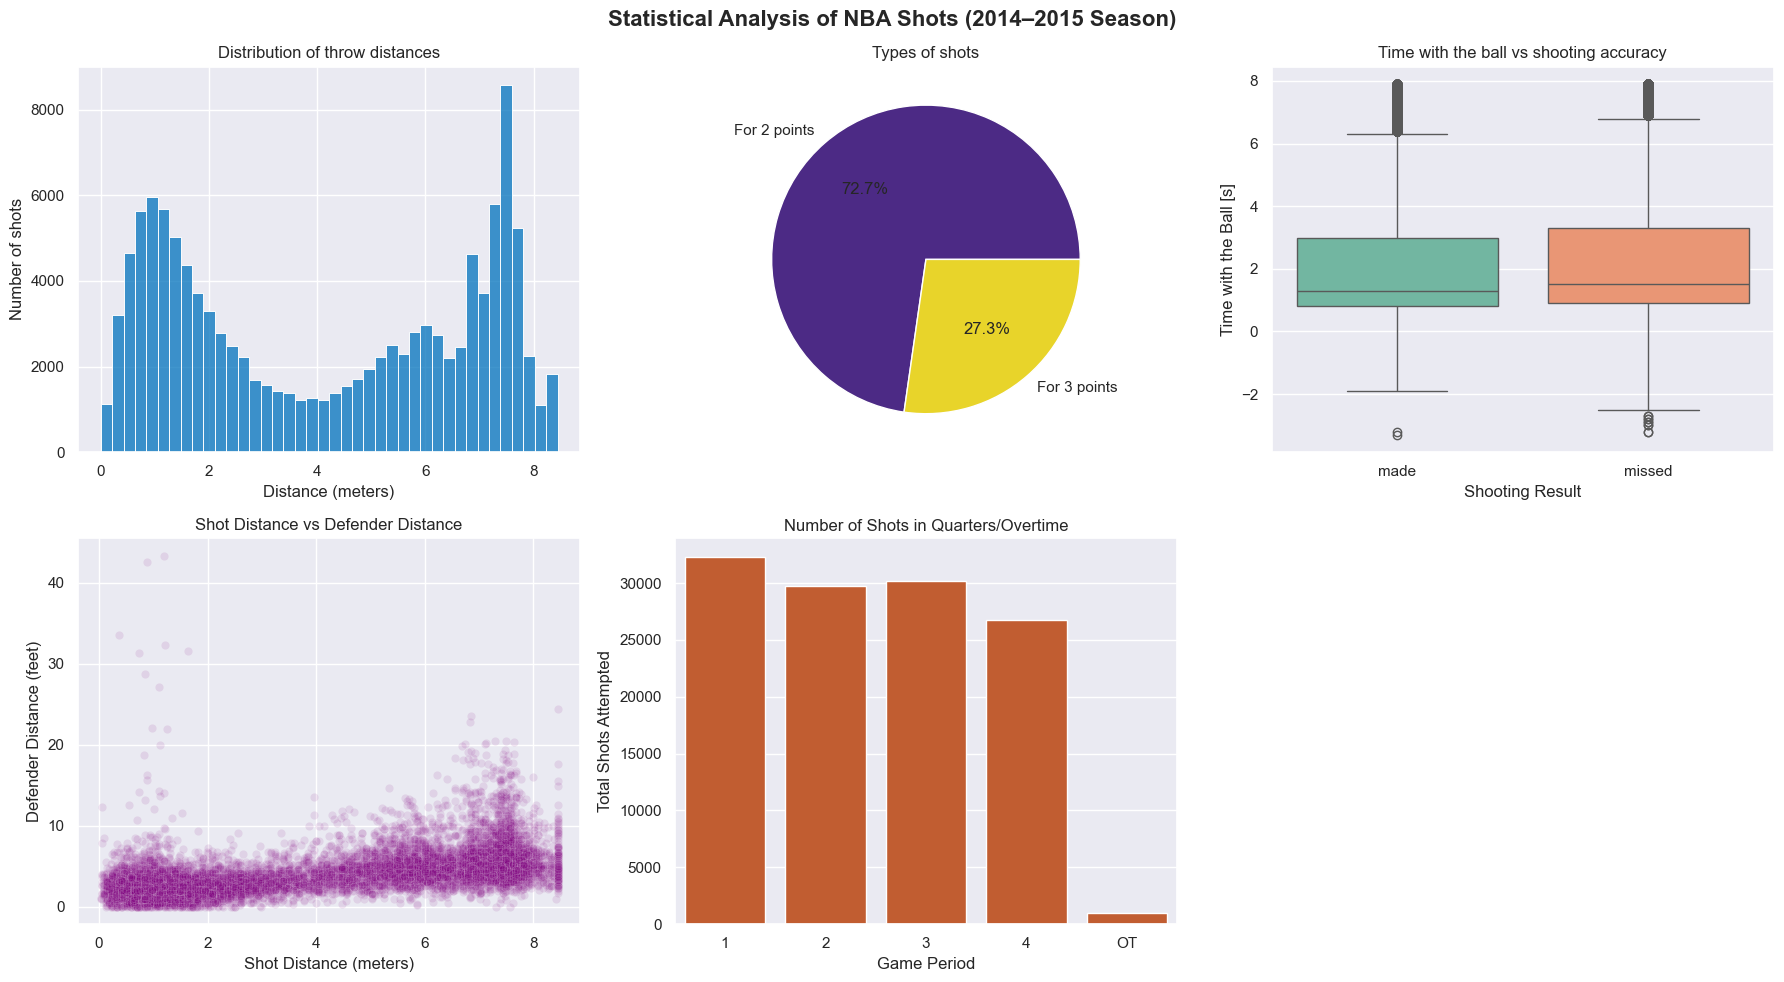

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Statistical Analysis of NBA Shots (2014–2015 Season)', fontsize=16, weight='bold')

# 1. Histogram – Throw distance distribution
sns.histplot(data=df, x='SHOT_DIST_M', bins=40, color='#0072BD', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of throw distances')
axes[0, 0].set_xlabel('Distance (meters)')
axes[0, 0].set_ylabel('Number of shots')

# 2. Pie chart – Shot types: 2-pt vs. 3-pt
type_of_shots = df['PTS_TYPE'].value_counts()
axes[0, 1].pie(type_of_shots, labels=['For 2 points', 'For 3 points'], autopct='%1.1f%%', colors=['#4C2A85', '#E8D42A'])
axes[0, 1].set_title('Types of shots')

# 3. Box plot – Time with the ball vs shooting accuracy
sns.boxplot(data=df, x='SHOT_RESULT', y='TOUCH_TIME', hue='SHOT_RESULT', palette='Set2', ax=axes[0, 2])
axes[0, 2].set_title('Time with the ball vs shooting accuracy')
axes[0, 2].set_xlabel('Shooting Result')
axes[0, 2].set_ylabel('Time with the Ball [s]')

# 4. Scatter plot – Shot distance vs Defender distance
sns.scatterplot(data=df.sample(10000), x='SHOT_DIST_M', y='CLOSE_DEF_DIST', alpha=0.1, color='purple', ax=axes[1, 0])
axes[1, 0].set_title('Shot Distance vs Defender Distance')
axes[1, 0].set_xlabel('Shot Distance (meters)')
axes[1, 0].set_ylabel('Defender Distance (feet)')

# 5. Bar plot – Number of shots in quarters
sns.countplot(data=df, x='PERIOD', order=['1', '2', '3', '4', 'OT'], color='#D95319', ax=axes[1, 1])
axes[1, 1].set_title('Number of Shots in Quarters/Overtime')
axes[1, 1].set_xlabel('Game Period')
axes[1, 1].set_ylabel('Total Shots Attempted')

# 6. Removing the empty 6th window.
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

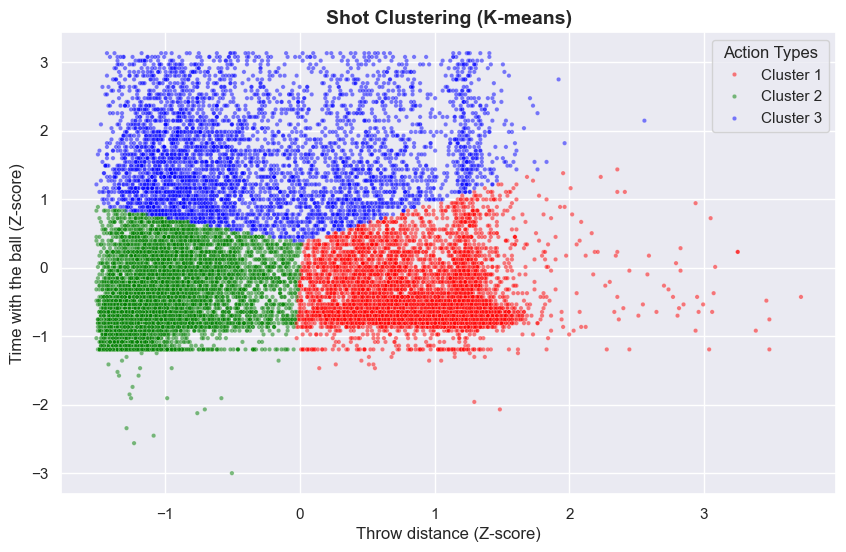

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Normalization (Z-score)
scaler = StandardScaler()
df.loc[:, ['SHOT_DIST_M', 'TOUCH_TIME']] = scaler.fit_transform(df[['SHOT_DIST_M', 'TOUCH_TIME']])

# 2. K-means clustering (dividing into 3 types of actions)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df.loc[:, 'action_type'] = kmeans.fit_predict(df[['SHOT_DIST_M', 'TOUCH_TIME']])

df.loc[:, 'action_type'] = df['action_type'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# 3. Clustering plot
plt.figure(figsize=(10, 6))
# We take a random sample of 20,000 rows so the plot renders quickly and is readable
sns.scatterplot(
    data=df.sample(20000, random_state=42),
    x='SHOT_DIST_M',
    y='TOUCH_TIME',
    hue='action_type',  # <--- TUTAJ JEST POPRAWKA
    palette=['red', 'green', 'blue'],
    alpha=0.5,
    s=10
)

plt.title('Shot Clustering (K-means)', fontsize=14, weight='bold') # <--- Przetłumaczony tytuł
plt.xlabel('Throw distance (Z-score)')
plt.ylabel('Time with the ball (Z-score)')
plt.legend(title='Action Types')
plt.show()
# Green - Fast shots from close range
# Red - Fast shots from long range
# Blue - Shots after long dribbling

Number of PCA components explaining 95% of variance: 3
Model accuracy on the test set: 53.7951%


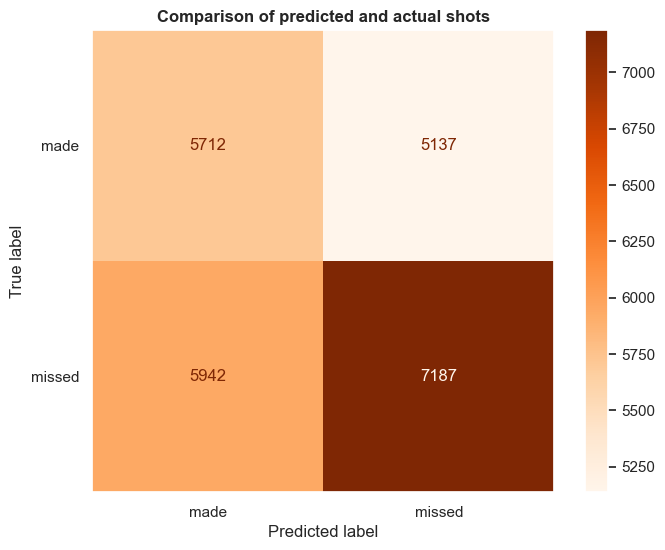

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Variables influencing the outcome (X) and the target variable (y)
X = df[['SHOT_DIST_M', 'TOUCH_TIME', 'DEF_PRESSURE']]
y = df['SHOT_RESULT']

# 2. Data split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. PCA component analysis
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Number of PCA components explaining 95% of variance: {pca.n_components_}")

# 4. Training the Decision Tree model
mdl = DecisionTreeClassifier(random_state=42)
mdl.fit(X_train_pca, y_train)

# 5. Prediction and model performance calculation
y_pred = mdl.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Model accuracy on the test set: {accuracy:.4f}%")

# 6. Generate confusion matrix for visualization
cm = confusion_matrix(y_test, y_pred, labels=mdl.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mdl.classes_)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(cmap='Oranges', ax=ax)
plt.title('Comparison of predicted and actual shots', weight='bold')
plt.grid(False)
plt.show()